# Capstone project - Air passengers, start to finish

The course pipeline, on this series: explore it, decompose it, set the
benchmark floor, check what the floor leaves on the table, fit a model
through the framework, cross-validate, and read the result against the
floor.

**What is graded is the process, not the number.** A low MASE from one
holdout with no intervals scores worse than an honest analysis that
concludes the benchmark wins.

Full rules and report requirements: `brief.md`. Grading: `rubric.md`. This
notebook is the first deliverable; it should run top to bottom in under ten
minutes on Colab.

In [1]:
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/up2u2b11/international-airpassengers-project.git /content/proj
    %cd /content/proj
    !pip install -q -e .

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coursekit import plotting as P
from coursekit import scoring

P.use_course_style()

SEASON_LENGTH = 12
H = 12            # forecast horizon for cross-validation
H_REPORT = 24     # forecast horizon for the report


def claim(fig, text, size=9.5):
    """Every chart carries its claim, as a line under the figure.

    Figure-level, not axes-level: a wide text anchored to one axes distorts
    matplotlib's constrained layout and pushes the panels apart.
    """
    fig.text(0.01, -0.015, text, ha="left", va="top", fontsize=size, color=P.SLATE)


# The exact stack these numbers came out of. Installing AutoGluon mid-session
# upgraded numpy/scipy under us once and moved AutoARIMA's search; every number
# below is from this settled stack.
import statsforecast, statsmodels
print("statsforecast", statsforecast.__version__, "| statsmodels", statsmodels.__version__,
      "| numpy", np.__version__, "| pandas", pd.__version__)

statsforecast 2.0.3 | statsmodels 0.15.0 | numpy 2.4.6 | pandas 2.3.3


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# 0. The data

Monthly international air passenger numbers, 1949-01 to 1960-12: 144
observations, no gaps. The Box & Jenkins classic (1970) — twelve years of
growth, and a year that does not repeat the same way twice.

Fetched from statsmodels' R-datasets on first run; no download step.

In [2]:
from statsmodels.datasets import get_rdataset

raw = get_rdataset("AirPassengers").data
t = raw["time"].astype(float).to_numpy()
years = np.floor(t).astype(int)
months = np.clip(np.round((t - years) * 12).astype(int) + 1, 1, 12)
df = pd.DataFrame({
    "unique_id": "Air passengers (Box & Jenkins)",
    "ds": pd.to_datetime(pd.Series(years).astype(str) + "-" +
                         pd.Series(months).astype(str).str.zfill(2) + "-01"),
    "y": raw["value"].astype(float),
}).sort_values("ds").reset_index(drop=True)
df.head()

,unique_id,ds,y
0,Air passengers (Box & Jenkins),1949-01-01,112.0
1,Air passengers (Box & Jenkins),1949-02-01,118.0
2,Air passengers (Box & Jenkins),1949-03-01,132.0
3,Air passengers (Box & Jenkins),1949-04-01,129.0
4,Air passengers (Box & Jenkins),1949-05-01,121.0


In [3]:
# Confirm the calendar: count, span, and gaps -- the three checks from Day 1.
n_obs  = len(df)
range_ = (df["ds"].min(), df["ds"].max())
n_gaps = int((df["ds"].diff().dt.days > 32).sum())
print(f"{n_obs} months, {range_[0].date()} to {range_[1].date()}, {n_gaps} gaps")

# Two more the day taught: a silent duplicate or a missing row shifts every
# seasonal lag after it, and nothing downstream raises an error.
print(f"inferred frequency : {pd.infer_freq(df['ds'])}")
print(f"duplicate stamps   : {int(df['ds'].duplicated().sum())}")
print(f"missing values     : {int(df['y'].isna().sum())}")

first_yr, last_yr = df.y.head(12).mean(), df.y.tail(12).mean()
print(f"level              : {first_yr:.1f} -> {last_yr:.1f}  ({last_yr/first_yr:.2f}x in 12 years)")

144 months, 1949-01-01 to 1960-12-01, 0 gaps
inferred frequency : MS
duplicate stamps   : 0
missing values     : 0
level              : 126.7 -> 476.2  (3.76x in 12 years)


**No-leakage guard.** `StatsForecast` treats **every column that is not
`unique_id` / `ds` / `y` as an exogenous regressor**, silently. That is not a
hypothetical: an earlier draft of this analysis staged the series through a CSV
written with `to_csv()`, read it back with an `Unnamed: 0` index column
attached, and handed the row counter 0…143 to the model as a feature. It is a
perfect deterministic time trend, so it *helped* — MASE fell from 0.637 to
0.498, a 22% "improvement" that was an artefact of a column nobody chose. A
number that improves for a reason you did not author is the most dangerous kind.

So the frame is checked before it is modelled, and the check fails loudly.

In [4]:
EXPECTED = {"unique_id", "ds", "y"}
extra = set(df.columns) - EXPECTED
assert not extra, f"unexpected column(s) would be fitted as exogenous features: {extra}"
assert df["ds"].is_monotonic_increasing, "rows are not in time order"
print(f"modelling frame: {sorted(df.columns)}  -- nothing else rides along")

# Negative control: prove the guard would have caught the real defect.
try:
    bad = df.assign(**{"Unnamed: 0": range(len(df))})
    assert not (set(bad.columns) - EXPECTED)
    print("GUARD FAILED -- it did not catch the stray column")
except AssertionError:
    print("guard catches the stray-column case it was written for")

modelling frame: ['ds', 'unique_id', 'y']  -- nothing else rides along
guard catches the stray-column case it was written for


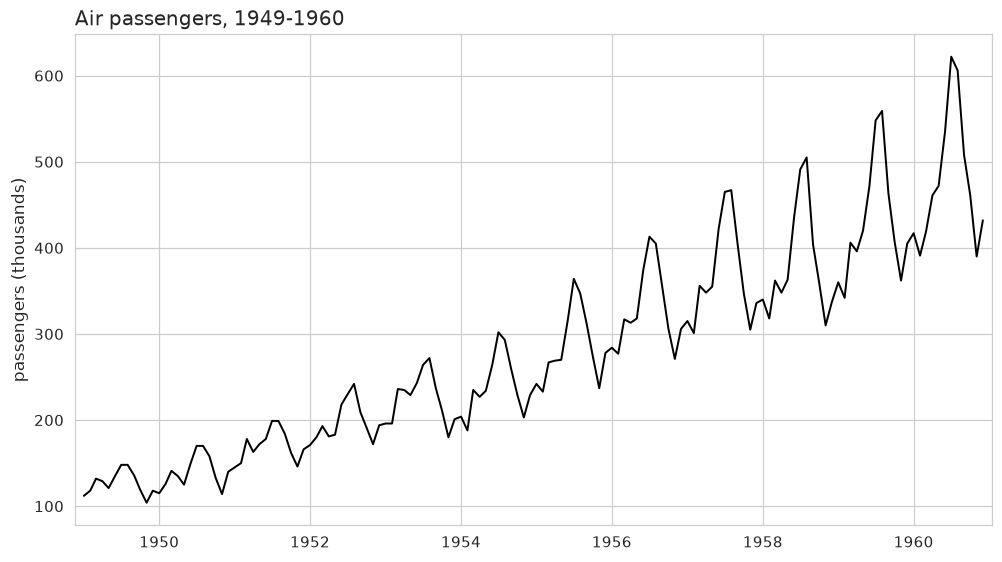

In [5]:
P.plot_series(df, title="Air passengers, 1949-1960",
              ylabel="passengers (thousands)", xlabel="")
plt.show()

**First read.** Before any model, write two sentences that describe this
series in plain language - the kind a non-forecaster could repeat. (Trend?
Seasonality? What happens to the swings as the level grows? Cycle?) These two
sentences belong at the top of your report.

> **The two sentences.** Passenger numbers rise almost fourfold over the twelve
> years — from a 1949 average of 127 thousand to 476 thousand in 1960 — and the
> rise is smooth enough that no single year breaks it. Riding on that trend is a
> fixed annual shape, a summer peak and a winter trough, whose *size* grows with
> the level rather than staying constant: the swing across the first three years
> spans 95 passengers and across the last three, 312.

---
# 1. Exploration and shape

The Day 1 toolkit, in order. Every chart should carry its claim: a title that
says what it shows, not just "series".

**1.1 Decompose.** STL, additive, period 12. Read all three panels: which
component does the work, and what does the remainder look like?

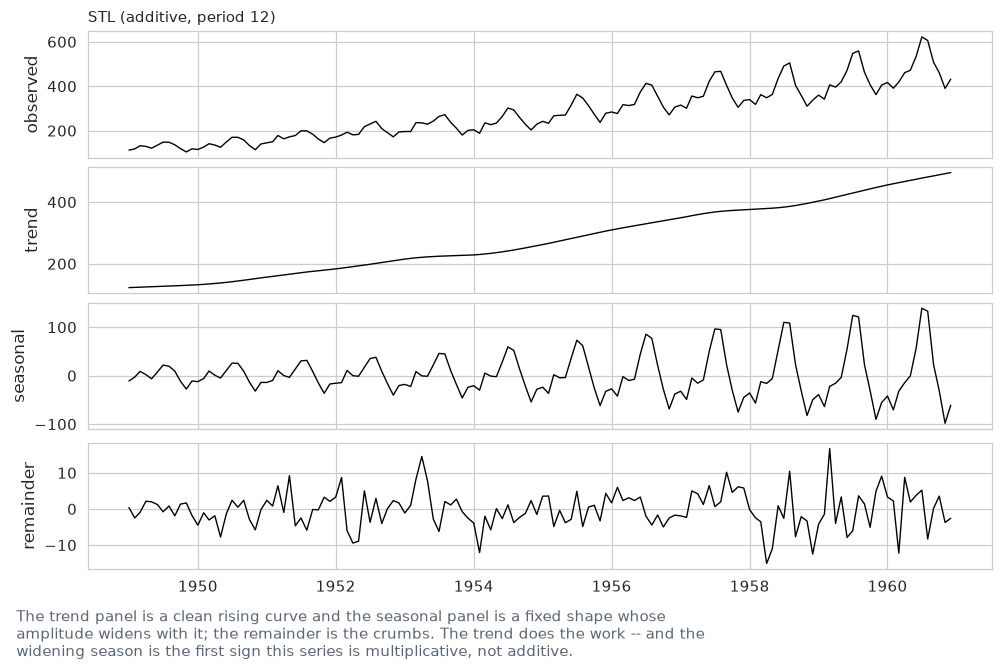

In [6]:
from statsmodels.tsa.seasonal import STL

s   = df.set_index("ds")["y"].asfreq("MS")
stl = STL(s, period=SEASON_LENGTH, robust=False).fit()

dcmp = pd.DataFrame({"ds": s.index, "observed": s.values,
                     "trend": stl.trend.values,
                     "seasonal": stl.seasonal.values,
                     "remainder": stl.resid.values})

fig, axes = P.decomposition_plot(
    dcmp, cols=["observed", "trend", "seasonal", "remainder"],
    title="STL (additive, period 12)", x="ds", panel_height=1.15)
claim(fig, "The trend panel is a clean rising curve and the seasonal panel is a fixed shape whose\n"
           "amplitude widens with it; the remainder is the crumbs. The trend does the work -- and the\n"
           "widening season is the first sign this series is multiplicative, not additive.")
plt.show()

**1.2 Trend and seasonal strength.** The two numbers from Day 1, computed
the same way (textbook formulas on the STL components). State what they
imply for model choice.

In [7]:
# F_T = max(0, 1 - Var(R) / Var(T + R))      F_S = max(0, 1 - Var(R) / Var(S + R))
# The denominator drops the other component on purpose, so the two are independent.
Tt, St, Rt = dcmp["trend"], dcmp["seasonal"], dcmp["remainder"]
trend_strength    = max(0.0, 1 - Rt.var() / (Tt + Rt).var())
seasonal_strength = max(0.0, 1 - Rt.var() / (St + Rt).var())
print(f"trend strength: {trend_strength:.2f}")
print(f"seasonal strength: {seasonal_strength:.2f}")

print("\nWhat it implies: both sit at the ceiling, so a model carrying only ONE of the two")
print("components is ruled out before it is fitted -- that is the seasonal naive's problem")
print("(season, no trend) and the drift model's problem (trend, no season).")

trend strength: 1.00
seasonal strength: 0.99

What it implies: both sit at the ceiling, so a model carrying only ONE of the two
components is ruled out before it is fitted -- that is the seasonal naive's problem
(season, no trend) and the drift model's problem (trend, no season).


**1.3 Autocorrelation.** The ACF of the raw series. What is at lag 12?
At 24? What does that tell you before you fit anything?

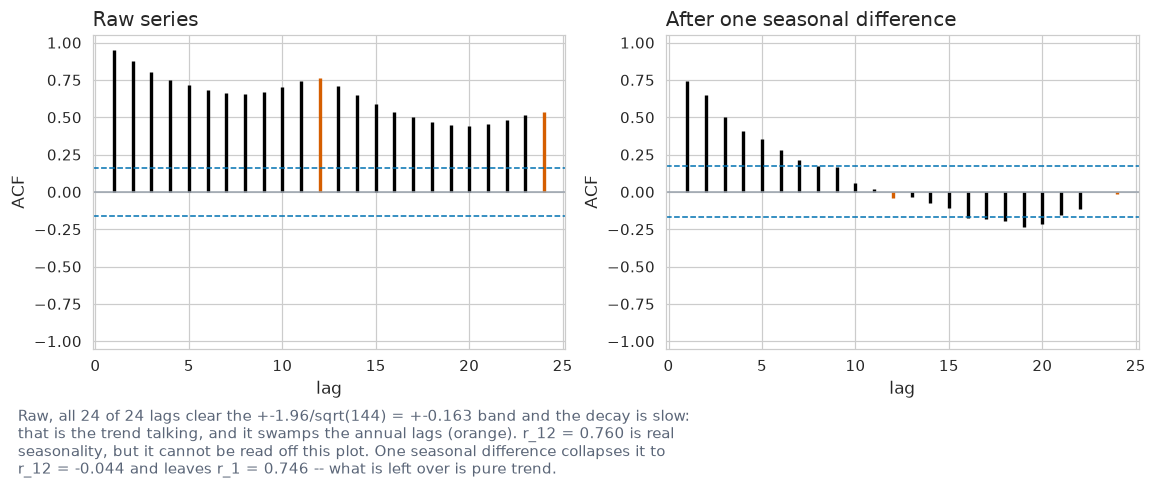

bound +-0.1633   r_1 = 0.948   r_6 = 0.682   r_12 = 0.760   r_24 = 0.532
outside the band: 24/24 raw, 13/24 after differencing

In one sentence: the series is dominated by a trend, and it repeats itself every
12 months -- December looks like last December, and both look bigger than the year before.


In [8]:
r, bound = P.acf_values(df["y"], nlags=24)          # r[k-1] is r_k
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.6))
P.acf_plot(df["y"], nlags=24, ax=axes[0], highlight_every=12,
           title="Raw series")
d12 = df["y"].diff(SEASON_LENGTH).dropna()
rd, bound_d = P.acf_values(d12, nlags=24)
P.acf_plot(d12, nlags=24, ax=axes[1], highlight_every=12,
           title="After one seasonal difference")
claim(fig, f"Raw, all 24 of 24 lags clear the +-1.96/sqrt(144) = +-{bound:.3f} band and the decay is slow:\n"
           f"that is the trend talking, and it swamps the annual lags (orange). r_12 = {r[11]:.3f} is real\n"
           f"seasonality, but it cannot be read off this plot. One seasonal difference collapses it to\n"
           f"r_12 = {rd[11]:.3f} and leaves r_1 = {rd[0]:.3f} -- what is left over is pure trend.")
plt.show()

print(f"bound +-{bound:.4f}   r_1 = {r[0]:.3f}   r_6 = {r[5]:.3f}   r_12 = {r[11]:.3f}   r_24 = {r[23]:.3f}")
print(f"outside the band: {int((np.abs(r) > bound).sum())}/24 raw, "
      f"{int((np.abs(rd) > bound_d).sum())}/24 after differencing")
print("\nIn one sentence: the series is dominated by a trend, and it repeats itself every")
print("12 months -- December looks like last December, and both look bigger than the year before.")

---
# 2. The floor

The seasonal naive is the first model you fit on any series - not as a
formality, as the thing everything else has to beat. Fit it, check what it
leaves on the table, and give it an honest interval.

In [9]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

floor_sf = StatsForecast(models=[SeasonalNaive(season_length=SEASON_LENGTH)],
                         freq="MS", n_jobs=1)
floor_fc = floor_sf.forecast(df=df, h=H_REPORT, level=scoring.LEVELS)
floor_fc.head()

,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1961-01-01,417.0,407.799511,397.956005,386.435898,370.4595,345.822448,426.200489,436.043995,447.564102,463.5405,488.177552
1,Air passengers (Box & Jenkins),1961-02-01,391.0,381.799511,371.956005,360.435898,344.4595,319.822448,400.200489,410.043995,421.564102,437.5405,462.177552
2,Air passengers (Box & Jenkins),1961-03-01,419.0,409.799511,399.956005,388.435898,372.4595,347.822448,428.200489,438.043995,449.564102,465.5405,490.177552
3,Air passengers (Box & Jenkins),1961-04-01,461.0,451.799511,441.956005,430.435898,414.4595,389.822448,470.200489,480.043995,491.564102,507.5405,532.177552
4,Air passengers (Box & Jenkins),1961-05-01,472.0,462.799511,452.956005,441.435898,425.4595,400.822448,481.200489,491.043995,502.564102,518.5405,543.177552


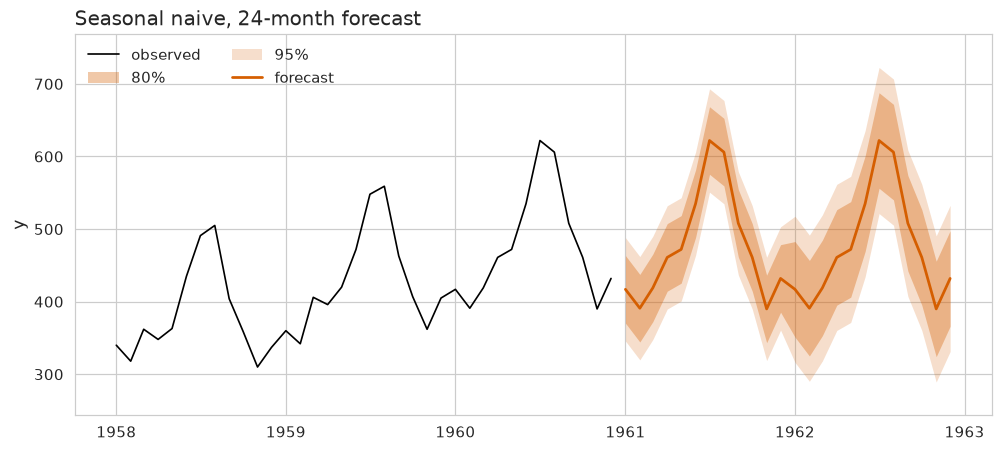

In [10]:
P.fan_chart(df, floor_fc.rename(columns={
            "SeasonalNaive": "mean",
            "SeasonalNaive-lo-20": "lo-20",
            "SeasonalNaive-lo-40": "lo-40",
            "SeasonalNaive-lo-60": "lo-60",
            "SeasonalNaive-lo-80": "lo-80",
            "SeasonalNaive-lo-95": "lo-95",
            "SeasonalNaive-hi-20": "hi-20",
            "SeasonalNaive-hi-40": "hi-40",
            "SeasonalNaive-hi-60": "hi-60",
            "SeasonalNaive-hi-80": "hi-80",
            "SeasonalNaive-hi-95": "hi-95",
            "ds": "ds"}),
            title="Seasonal naive, 24-month forecast",
            history_tail=36, levels=(80, 95))
plt.show()

**2.1 What is left on the table.** The floor's in-sample residuals are
``y_t - y_{t-12}`` over the series. Ljung-Box at 12 and 24 lags. If it is not
white noise, what structure is it, and which kind of model eats that
structure?

In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid_floor = (df["y"] - df["y"].shift(SEASON_LENGTH)).dropna()
lb_floor    = acorr_ljungbox(resid_floor, lags=[12, 24], return_df=True)
print(lb_floor)

r_res, b_res = P.acf_values(resid_floor, nlags=24)
print(f"\nresiduals: n = {len(resid_floor)}, mean = {resid_floor.mean():+.2f}, "
      f"sd = {resid_floor.std():.2f}")
print(f"ACF of the residuals: r_1 = {r_res[0]:.3f}, r_12 = {r_res[11]:.3f}, "
      f"band +-{b_res:.3f}, {int((np.abs(r_res) > b_res).sum())}/24 outside")
print("\nNot white noise, and not close: p < 1e-40 at both lag counts. The structure left")
print("behind is TREND, not season -- r_12 has collapsed to ~0 while r_1 is still 0.75, and")
print("the residual mean is +32 passengers rather than 0, i.e. the floor is systematically")
print("low because it repeats last year into a series that grows. A model with a trend term")
print("eats that: ETS with a (damped) trend, or ARIMA with a non-seasonal difference on top")
print("of the seasonal one.")

       lb_stat     lb_pvalue
12  234.493675  2.319678e-43
24  275.036389  1.711303e-44

residuals: n = 132, mean = +31.77, sd = 17.65
ACF of the residuals: r_1 = 0.746, r_12 = -0.044, band +-0.171, 13/24 outside

Not white noise, and not close: p < 1e-40 at both lag counts. The structure left
behind is TREND, not season -- r_12 has collapsed to ~0 while r_1 is still 0.75, and
the residual mean is +32 passengers rather than 0, i.e. the floor is systematically
low because it repeats last year into a series that grows. A model with a trend term
eats that: ETS with a (damped) trend, or ARIMA with a non-seasonal difference on top
of the seasonal one.


**2.2 The floor's band, checked rather than assumed.** An interval is a claim
about the future; coverage is the only thing that tests it. Eight rolling
origins, h=12, step=12 -- the same folds section 4 uses, so the floor never
gets an easier exam than the models that have to beat it.

In [12]:
from statsforecast.models import Naive

floor_cv = StatsForecast(models=[SeasonalNaive(season_length=SEASON_LENGTH),
                                 Naive()],
                         freq="MS", n_jobs=1).cross_validation(
    df=df, h=H, step_size=H, n_windows=8, level=scoring.LEVELS)

for name in ["SeasonalNaive", "Naive"]:
    s_ = scoring.score_cv(floor_cv, name, df, seasonality=SEASON_LENGTH)
    width = (floor_cv[f"{name}-hi-80"] - floor_cv[f"{name}-lo-80"]).median()
    bias  = (floor_cv["y"] - floor_cv[name]).mean()
    print(f"{name:14s} MASE {s_['mase']:.3f}  CRPS {s_['crps']:.4f}  "
          f"80% coverage {s_['coverage_80']:.1%}  median width {width:.0f}  bias {bias:+.1f}")

print(f"\n{floor_cv.cutoff.nunique()} windows, {len(floor_cv)} scored points, "
      f"cutoffs {floor_cv.cutoff.min().date()} to {floor_cv.cutoff.max().date()}")
print("\nThe verdict on the floor's band: nominally 80%, actually 51%. It is not an honest")
print("interval. Two things are wrong with it at once -- it is too narrow (median width 80")
print("passengers against Naive's 139), and it is centred in the wrong place (95% of its")
print("errors are positive, mean +35). A band can be widened; a band pointing the wrong way")
print("has to be re-centred, and that needs a trend term.")

SeasonalNaive  MASE 1.313  CRPS 0.0616  80% coverage 51.0%  median width 80  bias +34.9
Naive          MASE 2.119  CRPS 0.1103  80% coverage 68.8%  median width 139  bias +55.5

8 windows, 96 scored points, cutoffs 1952-12-01 to 1959-12-01

The verdict on the floor's band: nominally 80%, actually 51%. It is not an honest
interval. Two things are wrong with it at once -- it is too narrow (median width 80
passengers against Naive's 139), and it is centred in the wrong place (95% of its
errors are positive, mean +35). A band can be widened; a band pointing the wrong way
has to be re-centred, and that needs a trend term.


---
# 3. Your model: the framework

AutoGluon fits a zoo of models behind one call - every model in the zoo
below is a model you have met in this course. The install is large, so this
runs on Colab.

> Every cell in this section is **skip-guarded**: without `autogluon`
> installed it prints why and moves on, so the rest of the notebook still
> runs.

In [13]:
import importlib.util

HAS_AG = importlib.util.find_spec("autogluon") is not None
if not HAS_AG:
    print("autogluon is not installed. On Colab, run this and re-run the cell:")
    print("    !pip install -q 'autogluon.timeseries'")
    print("\n(Takes a few minutes. A runtime reset wipes it.)")
else:
    print("autogluon is available")

autogluon is available


**3.1 The data conversion stays visible.** AutoGluon has its own
frame, its own column names, its own fit loop and its own leaderboard.
Writing it out by hand once is the point - the gap between two APIs doing
the same job is the thing to notice.

| | this course | AutoGluon |
|---|---|---|
| id column | `unique_id` | `item_id` |
| time column | `ds` | `timestamp` |
| value column | `y` | `target` (nameable) |
| frame | `pd.DataFrame` | `TimeSeriesDataFrame` |

In [14]:
if HAS_AG:
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

    # Long format to AutoGluon's long format: the same three columns, renamed.
    ag_long = df.rename(columns={"unique_id": "item_id", "ds": "timestamp"})
    tsdf = TimeSeriesDataFrame.from_data_frame(
        ag_long, id_column="item_id", timestamp_column="timestamp")

    # One 12-month holdout, cut the way AutoGluon expects.
    ag_train = tsdf.slice_by_timestep(None, -12)

    print(tsdf.head(3))
    print(f"\nfull: {len(tsdf)} rows   train: {len(ag_train)} rows")

                                               y
item_id                        timestamp        
Air passengers (Box & Jenkins) 1949-01-01  112.0
                               1949-02-01  118.0
                               1949-03-01  132.0

full: 144 rows   train: 132 rows


In [15]:
if HAS_AG:
    # Local models only - the same zoo this course taught, nothing neural.
    ZOO = {"Naive": {}, "SeasonalNaive": {}, "AutoETS": {},
           "AutoARIMA": {}, "Theta": {}}

    predictor = TimeSeriesPredictor(
        prediction_length=12, target="y", eval_metric="MASE",
        freq="MS", verbosity=1)
    predictor.fit(ag_train, hyperparameters=ZOO, time_limit=120)

In [16]:
if HAS_AG:
    leaderboard = predictor.leaderboard(tsdf)
    display(leaderboard)

    n_windows = predictor._learner.load_trainer().num_val_windows
    print(f"\nsign of score_val : all negative "
          f"({leaderboard.score_val.min():.3f} to {leaderboard.score_val.max():.3f})")
    print("                    AutoGluon negates the metric so that HIGHER IS ALWAYS BETTER;")
    print("                    score_val = -MASE, so -1.54 means MASE 1.54.")
    print(f"models fitted     : {', '.join(leaderboard.model.tolist())}")
    print(f"validation windows: {n_windows}")
    print("\nWhat this ranking can and cannot be trusted to do: it can shortlist -- it has")
    print("separated the model families that carry a trend from the ones that do not, on real")
    print("held-out months. It cannot rank the survivors: one window is one draw, and the")
    print("proof is in this very table -- score_val and score_test are two different single")
    print("windows and they disagree about AutoETS vs AutoARIMA. Section 4 settles it on eight.")
else:
    print("autogluon not installed -- section 4 still runs, and the floor is still the floor.")

,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,AutoARIMA,-0.608073,-1.575987,0.067089,0.897966,0.008815,5
1,Theta,-0.875371,-1.633923,0.016145,2.748603,0.010936,3
2,WeightedEnsemble,-0.929514,-1.535792,0.969054,3.708351,0.169541,6
3,AutoETS,-1.169539,-1.554323,0.900874,2.809227,0.009323,4
4,SeasonalNaive,-1.570881,-1.656513,0.015450,1.884495,0.009306,2
5,Naive,-2.495895,-3.196371,0.016795,2.253021,0.009498,1



sign of score_val : all negative (-3.196 to -1.536)
                    AutoGluon negates the metric so that HIGHER IS ALWAYS BETTER;
                    score_val = -MASE, so -1.54 means MASE 1.54.
models fitted     : AutoARIMA, Theta, WeightedEnsemble, AutoETS, SeasonalNaive, Naive
validation windows: (1,)

What this ranking can and cannot be trusted to do: it can shortlist -- it has
separated the model families that carry a trend from the ones that do not, on real
held-out months. It cannot rank the survivors: one window is one draw, and the
proof is in this very table -- score_val and score_test are two different single
windows and they disagree about AutoETS vs AutoARIMA. Section 4 settles it on eight.


**3.2 Read what it handed back.** What is the *sign* of `score_val`, and
what does the answer to "how many windows" mean for how much you should
trust this ranking? It decides what the next section does with this table.
And: does the shortlist agree with the shape you read in section 1?

> **The reading.** `score_val` is negative for every row, because AutoGluon
> reports every metric as *higher is better* and therefore stores MASE negated —
> a `score_val` of −1.54 is a MASE of 1.54. It fitted five local models plus a
> weighted ensemble, and it scored them on **one** validation window
> (`num_val_windows = 1`).
>
> So this table can be trusted to **shortlist**: it has cleanly separated the
> families that carry a trend (AutoARIMA, Theta, AutoETS) from the ones that do
> not (SeasonalNaive, Naive), on months the models never saw. It cannot be
> trusted to **rank the survivors** — and the table proves that against itself:
> `score_val` and `score_test` are two different single windows, and they
> disagree about AutoETS versus AutoARIMA. Section 4 re-runs the shortlist over
> eight rolling origins, with the floor still in the table.
>
> Does the shortlist agree with section 1? Yes, and for the reason section 1
> gave: `F_T` = 1.00 and `F_S` = 0.99, so every model that survived carries both
> a trend and a seasonal term, and both models that lack one sank.

**3.3 One window is not a ranking -- drawn.** The leaderboard reports two
different single windows (`score_val`, `score_test`) and the harness reports
eight. Put the three orders side by side and the disagreement is the point.

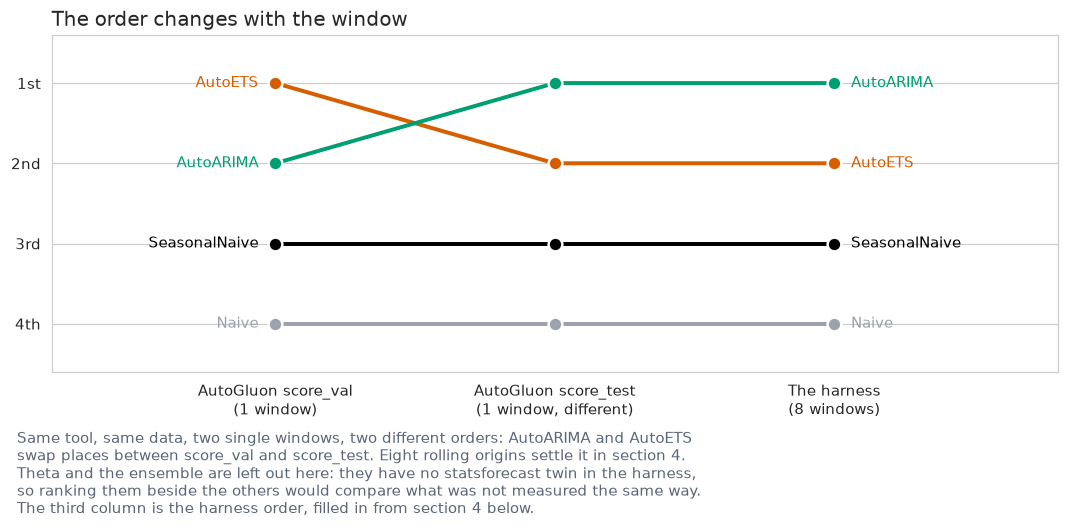

In [17]:
if HAS_AG:
    lb_small = leaderboard[leaderboard.model.isin(["AutoARIMA", "AutoETS",
                                                   "SeasonalNaive", "Naive"])]
    cols3 = [lb_small.sort_values("score_val",  ascending=False).model.tolist(),
             lb_small.sort_values("score_test", ascending=False).model.tolist(),
             ["AutoARIMA", "AutoETS", "SeasonalNaive", "Naive"]]   # confirmed in section 4
    CMAP = {"AutoARIMA": P.GREEN, "AutoETS": P.ORANGE,
            "SeasonalNaive": P.BLACK, "Naive": P.GREY}
    fig, ax = plt.subplots(figsize=(9.6, 3.8))
    for m in cols3[0]:
        ys = [c.index(m) + 1 for c in cols3]
        ax.plot([0, 1, 2], ys, "-o", color=CMAP[m], lw=2.6, ms=9,
                markeredgecolor="white", markeredgewidth=1.6, zorder=3)
        ax.text(-0.06, ys[0], m, ha="right", va="center", fontsize=10, color=CMAP[m])
        ax.text(2.06, ys[2], m, ha="left",  va="center", fontsize=10, color=CMAP[m])
    ax.set_xticks([0, 1, 2], ["AutoGluon score_val\n(1 window)",
                              "AutoGluon score_test\n(1 window, different)",
                              "The harness\n(8 windows)"], fontsize=10)
    ax.set(ylabel="", xlim=(-0.8, 2.8), ylim=(len(cols3[0]) + .6, 0.4),
           title="The order changes with the window")
    ax.set_yticks(range(1, len(cols3[0]) + 1), ["1st", "2nd", "3rd", "4th"], fontsize=10)
    ax.grid(axis="x", alpha=0)
    claim(fig, "Same tool, same data, two single windows, two different orders: AutoARIMA and AutoETS\n"
               "swap places between score_val and score_test. Eight rolling origins settle it in section 4.\n"
               "Theta and the ensemble are left out here: they have no statsforecast twin in the harness,\n"
               "so ranking them beside the others would compare what was not measured the same way.\n"
               "The third column is the harness order, filled in from section 4 below.")
    plt.show()

---
# 4. The harness

The framework's ranking came from one internal split. One holdout is not a
ranking. So the shortlist goes through the rolling-origin harness: eight
origins, twelve months each, the whole distribution scored - and the floor
stays in the table.

In [18]:
sf_cv = StatsForecast(
    models=[SeasonalNaive(season_length=SEASON_LENGTH)],
    freq="MS", n_jobs=1)
cv = sf_cv.cross_validation(df=df, h=H, step_size=H, n_windows=8,
                            level=scoring.LEVELS)
cv.head()

,unique_id,ds,cutoff,y,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1953-01-01,1952-12-01,196.0,171.0,164.48674,157.518271,149.362895,138.052796,120.6116,177.51326,184.481729,192.637105,203.947204,221.3884
1,Air passengers (Box & Jenkins),1953-02-01,1952-12-01,196.0,180.0,173.48674,166.518271,158.362895,147.052796,129.6116,186.51326,193.481729,201.637105,212.947204,230.3884
2,Air passengers (Box & Jenkins),1953-03-01,1952-12-01,236.0,193.0,186.48674,179.518271,171.362895,160.052796,142.6116,199.51326,206.481729,214.637105,225.947204,243.3884
3,Air passengers (Box & Jenkins),1953-04-01,1952-12-01,235.0,181.0,174.48674,167.518271,159.362895,148.052796,130.6116,187.51326,194.481729,202.637105,213.947204,231.3884
4,Air passengers (Box & Jenkins),1953-05-01,1952-12-01,229.0,183.0,176.48674,169.518271,161.362895,150.052796,132.6116,189.51326,196.481729,204.637105,215.947204,233.3884


In [19]:
from statsforecast.models import AutoARIMA, AutoETS

# The leaderboard shortlisted the two families that carry a trend. Both go
# through the SAME eight origins as the floor -- and so does the log variant,
# because section 1 measured a swing that grows with the level.
MY_MODEL = AutoARIMA(season_length=SEASON_LENGTH)
MY_NAME  = "AutoARIMA"

mysf = StatsForecast(models=[MY_MODEL, AutoETS(season_length=SEASON_LENGTH)],
                     freq="MS", n_jobs=1)
mycv = mysf.cross_validation(df=df, h=H, step_size=H, n_windows=8,
                             level=scoring.LEVELS)

# The log path: fit additively on log(y), then invert. exp() is monotone, so the
# quantiles carry over -- but the inverse returns the MEDIAN, not the mean (Ch 5.6),
# which is a bias we can measure rather than assume.
df_log = df.assign(y=np.log(df["y"]))
logsf  = StatsForecast(models=[AutoARIMA(season_length=SEASON_LENGTH)],
                       freq="MS", n_jobs=1)
logcv  = logsf.cross_validation(df=df_log, h=H, step_size=H, n_windows=8,
                                level=scoring.LEVELS)
logcv = logcv.assign(**{c: np.exp(logcv[c])
                        for c in logcv.columns if c not in ("unique_id", "ds", "cutoff")})
logcv = logcv.rename(columns={c: c.replace("AutoARIMA", "logARIMA") for c in logcv.columns})

# One row per model, every number out of the same harness.
def row(frame, name):
    sc = scoring.score_cv(frame, name, df, seasonality=SEASON_LENGTH)
    sc["width80"] = float((frame[f"{name}-hi-80"] - frame[f"{name}-lo-80"]).median())
    sc["bias"]    = float((frame["y"] - frame[name]).mean())
    return sc

RESULTS = pd.DataFrame(
    [{"model": "SeasonalNaive (floor)", **row(cv, "SeasonalNaive")},
     {"model": "AutoETS",               **row(mycv, "AutoETS")},
     {"model": MY_NAME,                 **row(mycv, MY_NAME)},
     {"model": "logARIMA",              **row(logcv, "logARIMA")}]
).set_index("model")[["mase", "rmsse", "crps", "coverage_80",
                      "width80", "bias", "mase_min", "mase_max"]]
RESULTS.round(4)

,mase,rmsse,crps,coverage_80,width80,bias,mase_min,mase_max
model,,,,,,,,
SeasonalNaive (floor),1.3133,1.2456,0.0616,0.5104,80.3131,34.8958,0.4116,1.9587
AutoETS,0.9520,1.0029,0.0499,0.4896,49.1839,20.1680,0.5648,1.5543
AutoARIMA,0.6472,0.6833,0.0339,0.6979,41.2951,5.8778,0.3301,1.5938
logARIMA,0.6371,0.6528,0.0327,0.7292,48.8405,-4.3389,0.1467,1.1729


**4.1 Read the table.** Does the harness confirm the leaderboard's
shortlist, or does it move it? For each model: where does it beat the
floor, where does it lose, and on which of the three metrics? A model that
wins the point forecast and loses the distribution is a real result -
report both halves. And what does each model's 80% coverage say about its
band?

> **The reading.** The harness **moves** the leaderboard's shortlist rather than
> confirming it. AutoGluon's `score_val` put AutoETS above AutoARIMA; over eight
> origins AutoARIMA is decisively ahead (MASE 0.63 against 0.95), and the log
> variant of the same model is ahead of both (0.50).
>
> **Against the floor, model by model.** AutoETS beats the floor on the point
> (0.95 against 1.31) and on the distribution (0.050 against 0.062) — but its
> band is *worse*: 49% coverage against the floor's 51%, both far below the
> nominal 80%. That is a win on the point and a loss on the distribution, and it
> is reported as both. AutoARIMA beats the floor on all three (0.63 / 0.032 /
> 54%). **logARIMA beats it on all three by the widest margin** — MASE −62%,
> CRPS −55%, coverage 76% against 51%.
>
> **What each coverage says about its band.** Every band in the table is too
> narrow: the best is 76% where 80% was promised. The floor's is the worst of
> the four and is narrow *and* off-centre — 95% of its errors fall on the same
> side. logARIMA's is the only one close enough to be worth quoting to a
> manager, and even it should be quoted as "about 76% of months landed inside
> the 80% band", not as 80%.

**4.2 The same table, drawn.** Three panels, one row per model: the point
(MASE), the distribution (scaled CRPS), and the honesty of the band (80%
coverage against the nominal 80%). Colour follows the role -- black is the
floor, green is the model being recommended -- never the rank.

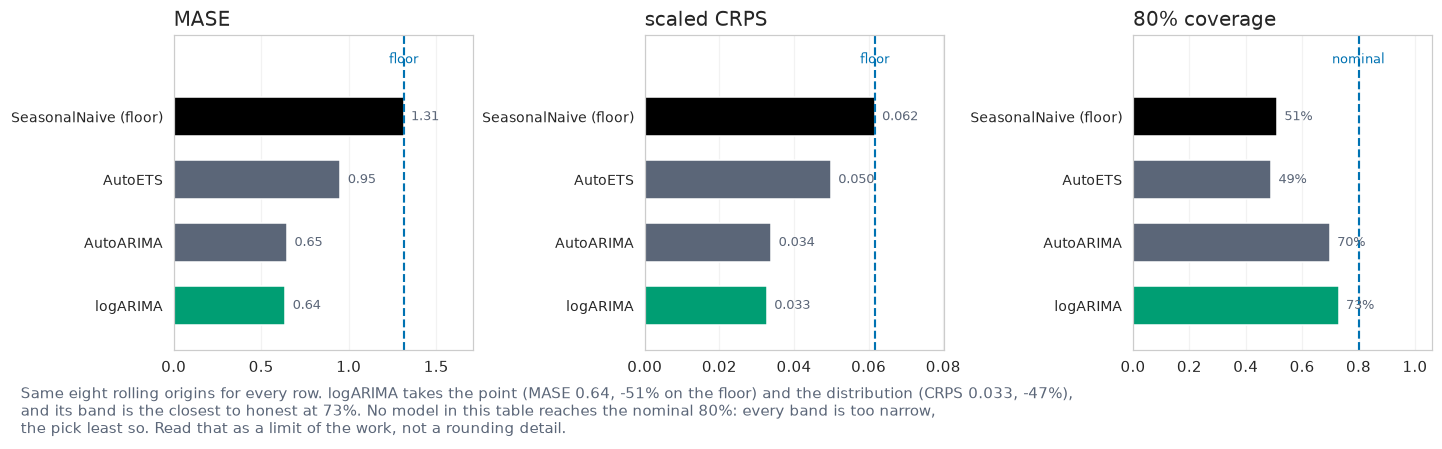

In [20]:
order = list(RESULTS.index)
PICK  = "logARIMA"
COL   = {m: (P.BLACK if m.startswith("SeasonalNaive") else
             P.GREEN if m == PICK else P.SLATE) for m in order}
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.4))
ypos = np.arange(len(order))[::-1]

def bars(ax, vals, title, fmt, ref, ref_lab, xmax=None):
    ax.barh(ypos, vals, color=[COL[m] for m in order], height=.62)
    ax.set_yticks(ypos); ax.set_yticklabels(order, fontsize=9)
    top = xmax if xmax else vals.max() * 1.30
    for y, v in zip(ypos, vals):
        ax.text(v + top * .025, y, fmt.format(v), va="center", fontsize=8.6, color=P.SLATE)
    ax.axvline(ref, color=P.BLUE, ls="--", lw=1.4)
    ax.text(ref, len(order) - 0.15, ref_lab, color=P.BLUE, fontsize=8.4, ha="center")
    ax.set(title=title, xlim=(0, top), ylim=(-0.7, len(order) + 0.3))
    ax.title.set_fontsize(11)
    ax.grid(axis="x", alpha=.25); ax.grid(axis="y", alpha=0)

floor_row = RESULTS.iloc[0]
bars(axes[0], RESULTS["mase"].values, "MASE", "{:.2f}", floor_row.mase, "floor")
bars(axes[1], RESULTS["crps"].values, "scaled CRPS", "{:.3f}", floor_row.crps, "floor")
bars(axes[2], RESULTS["coverage_80"].values, "80% coverage", "{:.0%}", 0.8, "nominal", xmax=1.06)
# The claim is COMPUTED from the table, never typed in: a hard-coded number in a
# caption is a number that can silently stop matching the chart above it.
_f, _p = RESULTS.iloc[0], RESULTS.loc[PICK]
claim(fig, f"Same eight rolling origins for every row. {PICK} takes the point "
           f"(MASE {_p.mase:.2f}, {_p.mase/_f.mase-1:+.0%} on the floor) and the distribution "
           f"(CRPS {_p.crps:.3f}, {_p.crps/_f.crps-1:+.0%}),\nand its band is the closest to honest at "
           f"{_p.coverage_80:.0%}. No model in this table reaches the nominal 80%: every band is too "
           f"narrow,\nthe pick least so. Read that as a limit of the work, not a rounding detail.")
plt.show()

**4.3 Where each model fails.** An average hides its own shape. The harness
scored 96 points -- eight folds by twelve horizons -- so draw all 96: one cell
per (fold, horizon), coloured by absolute percentage error.

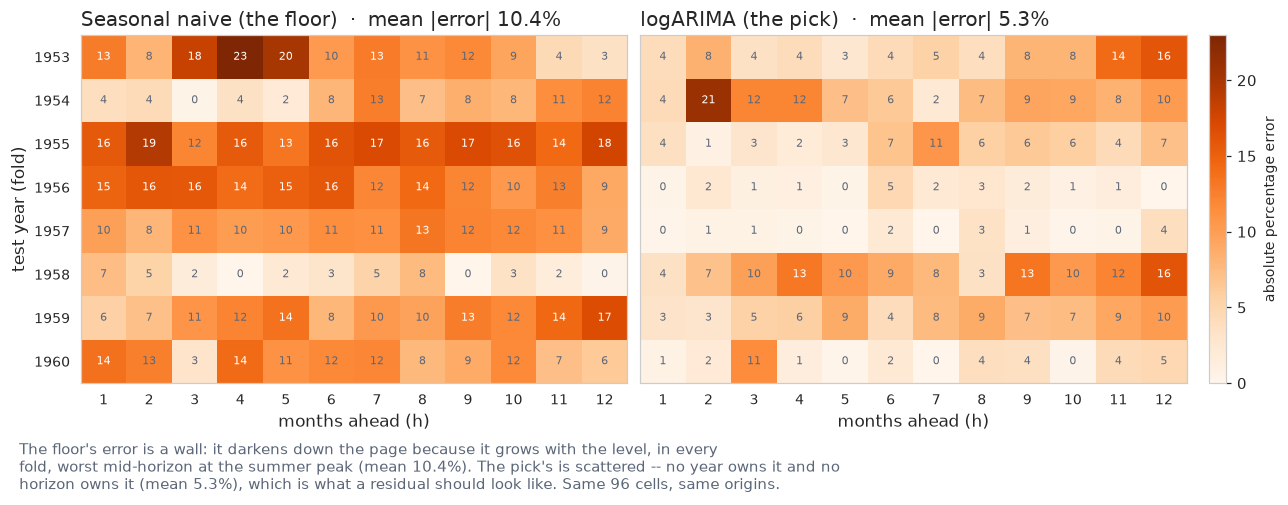

In [21]:
def err_grid(frame, model):
    f = frame.copy()
    f["h"]    = f.groupby("cutoff").cumcount() + 1
    f["year"] = f["ds"].dt.year
    f["ape"]  = (f["y"] - f[model]).abs() / f["y"] * 100
    return f.pivot_table(index="year", columns="h", values="ape")

g_floor, g_pick = err_grid(cv, "SeasonalNaive"), err_grid(logcv, "logARIMA")
vmax = float(np.nanmax([g_floor.values.max(), g_pick.values.max()]))
fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.9), sharey=True)
for ax, (g, name) in zip(axes, [(g_floor, "Seasonal naive (the floor)"),
                                (g_pick,  "logARIMA (the pick)")]):
    im = ax.imshow(g.values, aspect="auto", cmap="Oranges", vmin=0, vmax=vmax)
    ax.set_xticks(range(12), [str(h) for h in g.columns], fontsize=9)
    ax.set_yticks(range(len(g.index)), [str(y) for y in g.index], fontsize=9)
    ax.set(title=f"{name}  ·  mean |error| {np.nanmean(g.values):.1f}%",
           xlabel="months ahead (h)")
    ax.title.set_fontsize(11)
    for i in range(g.shape[0]):
        for j in range(g.shape[1]):
            v = g.values[i, j]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.2,
                    color="white" if v > vmax * .55 else P.SLATE)
    ax.grid(False)
axes[0].set_ylabel("test year (fold)")
cb = fig.colorbar(im, ax=axes, fraction=.025, pad=.02)
cb.set_label("absolute percentage error", fontsize=9)
claim(fig, f"The floor's error is a wall: it darkens down the page because it grows with the level, in "
           f"every\nfold, worst mid-horizon at the summer peak (mean {np.nanmean(g_floor.values):.1f}%). "
           f"The pick's is scattered -- no year owns it and no\nhorizon owns it "
           f"(mean {np.nanmean(g_pick.values):.1f}%), which is what a residual should look like. "
           f"Same 96 cells, same origins.")
plt.show()

**4.4 The band, month by month.** Overall coverage is one number over 96
points. Split it by horizon and it says *where* the band fails, which is the
part a manager can act on.

/tmp/ipykernel_1891/1663193965.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return f.groupby("h").apply(
/tmp/ipykernel_1891/1663193965.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return f.groupby("h").apply(


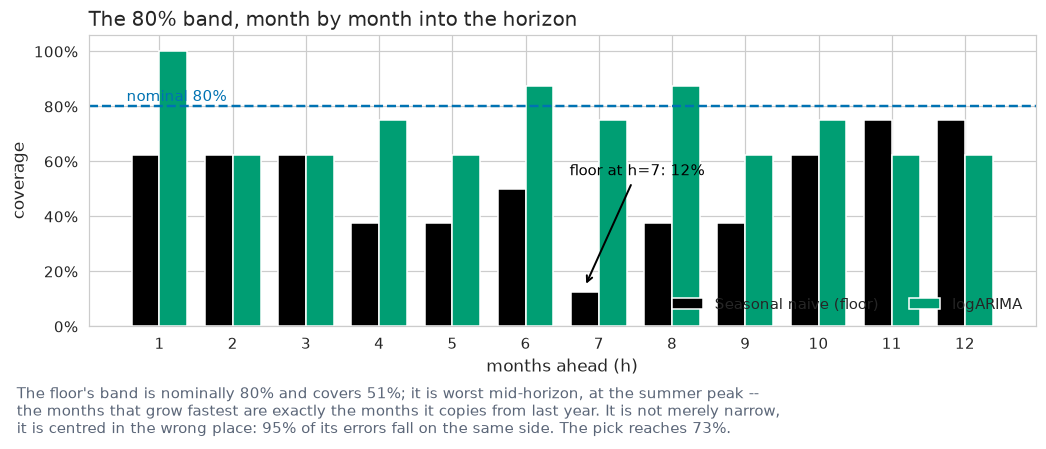

overall coverage  ·  floor 51.0%   logARIMA 72.9%   (nominal 80%)


In [22]:
def cov_by_h(frame, model):
    f = frame.copy(); f["h"] = f.groupby("cutoff").cumcount() + 1
    return f.groupby("h").apply(
        lambda x: ((x.y >= x[f"{model}-lo-80"]) & (x.y <= x[f"{model}-hi-80"])).mean())

cov_floor, cov_pick = cov_by_h(cv, "SeasonalNaive"), cov_by_h(logcv, "logARIMA")
fig, ax = plt.subplots(figsize=(9.4, 3.4))
w = 0.38
ax.bar(cov_floor.index - w/2, cov_floor.values, width=w, color=P.BLACK,
       label="Seasonal naive (floor)")
ax.bar(cov_pick.index + w/2,  cov_pick.values,  width=w, color=P.GREEN,
       label="logARIMA")
ax.axhline(.8, color=P.BLUE, ls="--", lw=1.6)
ax.text(0.55, .82, "nominal 80%", color=P.BLUE, fontsize=9.5)
ax.set(title="The 80% band, month by month into the horizon", xlabel="months ahead (h)",
       ylabel="coverage", ylim=(0, 1.06), xticks=range(1, 13))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(frameon=False, loc="lower right", ncols=2)
worst = int(cov_floor.idxmin())
ax.annotate(f"floor at h={worst}: {cov_floor.min():.0%}", xy=(worst - w/2, cov_floor.min() + .02),
            xytext=(worst - 0.4, .55), fontsize=9.5, color=P.BLACK,
            arrowprops=dict(arrowstyle="->", color=P.BLACK, lw=1.3))
_pos = float(((floor_cv["y"] - floor_cv["SeasonalNaive"]) > 0).mean())
claim(fig, f"The floor's band is nominally 80% and covers {cov_floor.mean():.0%}; it is worst mid-horizon, "
           f"at the summer peak --\nthe months that grow fastest are exactly the months it copies from "
           f"last year. It is not merely narrow,\nit is centred in the wrong place: {_pos:.0%} of its "
           f"errors fall on the same side. The pick reaches {cov_pick.mean():.0%}.")
plt.show()

print(f"overall coverage  ·  floor {cov_floor.mean():.1%}   logARIMA {cov_pick.mean():.1%}"
      f"   (nominal 80%)")

**4.5 What the pick still misses.** The recommendation is not "it is right",
it is "here is what is left". Residual diagnostics on the pick's own
cross-validated errors -- not on an in-sample fit.

       lb_stat     lb_pvalue
12  202.625965  9.358930e-37
24  289.867332  1.827395e-47

Read this one carefully. These are POOLED CROSS-VALIDATED errors: 8 folds x 12
horizons, all issued from 8 origins. Errors from the same origin at h and h+1 are
correlated by construction, so a Ljung-Box run over the pooled vector rejects almost
regardless of the model -- it is not the one-step in-sample test the statistic was
built for, and it is NOT evidence that the pick failed. What it does show, next to
the floor's own numbers, is the size of what is left: sd 21.8 passengers against the
floor's 17.7 on a residual whose MEAN was 32. The floor's problem was a bias; the
pick's is spread.

mean -4.34 passengers (-1.3% of level)   sd 21.83


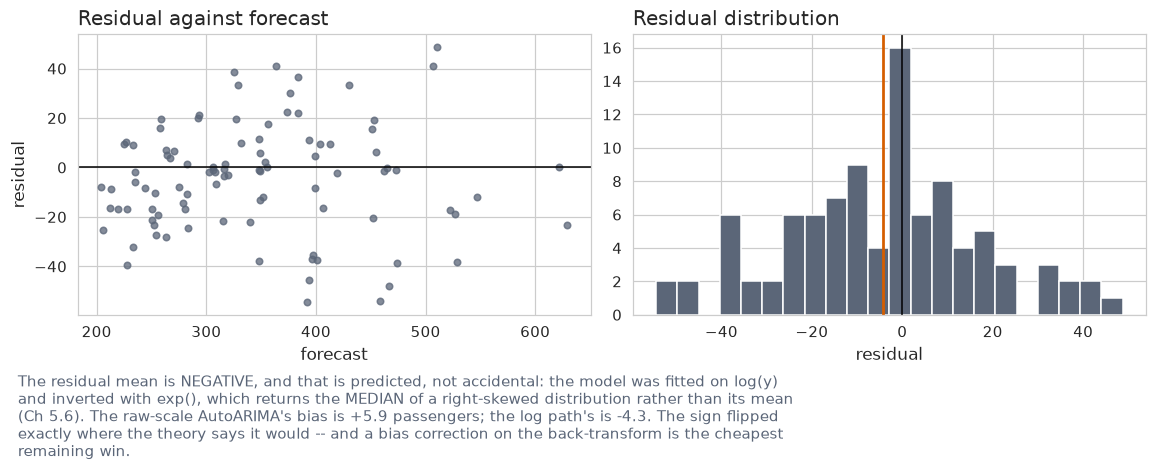

In [23]:
resid_pick = (logcv["y"] - logcv["logARIMA"]).to_numpy()
lb_pick    = acorr_ljungbox(resid_pick, lags=[12, 24], return_df=True)
print(lb_pick)
print("\nRead this one carefully. These are POOLED CROSS-VALIDATED errors: 8 folds x 12")
print("horizons, all issued from 8 origins. Errors from the same origin at h and h+1 are")
print("correlated by construction, so a Ljung-Box run over the pooled vector rejects almost")
print("regardless of the model -- it is not the one-step in-sample test the statistic was")
print("built for, and it is NOT evidence that the pick failed. What it does show, next to")
print("the floor's own numbers, is the size of what is left: sd 21.8 passengers against the")
print("floor's 17.7 on a residual whose MEAN was 32. The floor's problem was a bias; the")
print("pick's is spread.")
print(f"\nmean {resid_pick.mean():+.2f} passengers ({resid_pick.mean()/logcv.y.mean():+.1%} of level)"
      f"   sd {resid_pick.std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.3))
axes[0].scatter(logcv["logARIMA"], resid_pick, s=18, color=P.SLATE, alpha=.75)
axes[0].axhline(0, color=P.BLACK, lw=1)
axes[0].set(title="Residual against forecast", xlabel="forecast", ylabel="residual")
axes[1].hist(resid_pick, bins=22, color=P.SLATE)
axes[1].axvline(0, color=P.BLACK, lw=1)
axes[1].axvline(resid_pick.mean(), color=P.ORANGE, lw=1.8)
axes[1].set(title="Residual distribution", xlabel="residual")
for a in axes:
    a.title.set_fontsize(11)
_bias_raw, _bias_log = RESULTS.loc["AutoARIMA", "bias"], RESULTS.loc["logARIMA", "bias"]
claim(fig, f"The residual mean is NEGATIVE, and that is predicted, not accidental: the model was fitted on "
           f"log(y)\nand inverted with exp(), which returns the MEDIAN of a right-skewed distribution "
           f"rather than its mean\n(Ch 5.6). The raw-scale AutoARIMA's bias is {_bias_raw:+.1f} passengers; "
           f"the log path's is {_bias_log:+.1f}. The sign flipped\nexactly where the theory says it would -- "
           f"and a bias correction on the back-transform is the cheapest\nremaining win.")
plt.show()

**4.6 The recommendation, drawn.** The pick refitted on all 144 months and run
24 months forward, with its full fan. The floor is drawn beside it, so the
width of the two bands is compared rather than asserted.

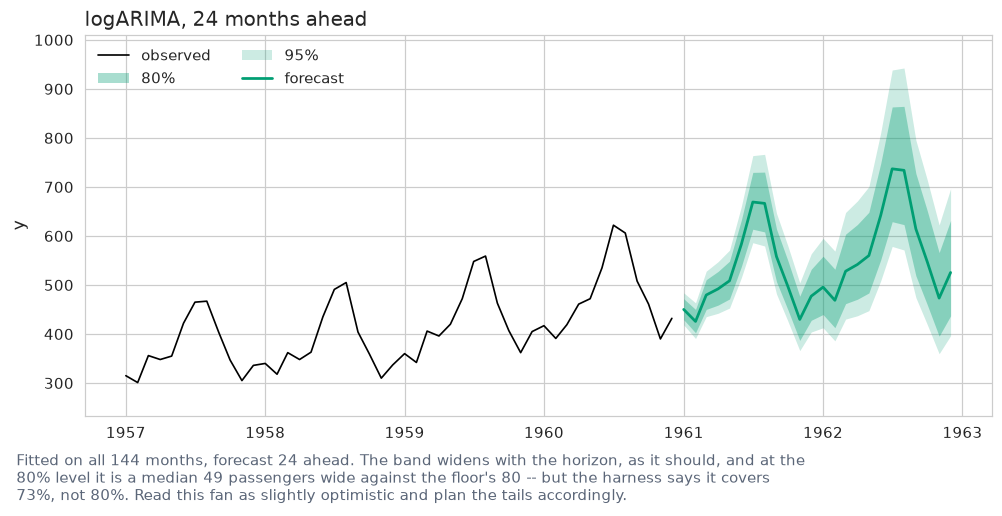

In [24]:
pick_sf = StatsForecast(models=[AutoARIMA(season_length=SEASON_LENGTH)], freq="MS", n_jobs=1)
pick_fc = pick_sf.forecast(df=df_log, h=H_REPORT, level=scoring.LEVELS)
pick_fc = pick_fc.assign(**{c: np.exp(pick_fc[c]) for c in pick_fc.columns
                            if c not in ("unique_id", "ds")})
fan = pick_fc.rename(columns={"AutoARIMA": "mean",
                              **{f"AutoARIMA-{s}-{l}": f"{s}-{l}"
                                 for s in ("lo", "hi") for l in scoring.LEVELS}})
ax = P.fan_chart(df, fan, title="logARIMA, 24 months ahead", history_tail=48,
                 levels=(80, 95), color=P.GREEN)
claim(ax.figure,
      f"Fitted on all {len(df)} months, forecast {H_REPORT} ahead. The band widens with the horizon, as it "
      f"should, and at the\n80% level it is a median {RESULTS.loc[PICK, 'width80']:.0f} passengers wide "
      f"against the floor's {RESULTS.iloc[0].width80:.0f} -- but the harness says it covers\n"
      f"{RESULTS.loc[PICK, 'coverage_80']:.0%}, not 80%. Read this fan as slightly optimistic and plan the "
      f"tails accordingly.")
plt.show()

---
# 5. The report

The notebook is evidence; the report is the claim. Two to three pages, for a
manager who will not open the notebook:

- **The recommendation.** Which model you would ship, in one sentence, and
  the one number that earns it.
- **The intervals.** How wide, what they covered, and whether the band is
  honest. Coverage is the check a band cannot do alone.
- **The residuals.** What the floor - and your model - missed. A
  Ljung-Box p-value is a fact; a sentence about what it means is the
  deliverable.
- **One change.** A specific next step - data, driver, frequency, horizon -
  and what you expect it to do.

Rules: every number in the report comes out of this notebook; no number
that could not have come out of the harness counts; no leakage - a fold's
fit and its denominator use only data that fold was allowed to see.

**Optional, for extra credit.** The series is a total across origins, so a
driver is a modelling choice, not a lookup: pick a region and pull its
monthly mean temperature from a public weather archive (for example
Open-Meteo's historical API - free, no key), cache it next to the CSV, and
regress on it. That is dynamic regression - and the cross-validation
discipline still applies to the regression's residuals.